# Cambiar Path absoluto a relativo para resolver path no encontrado en depth_metrics.csv

In [34]:
import csv
from pathlib import Path

# =========================
# CONFIG
# =========================
CSV_IN  = Path("Manzana/csv/depth_metrics.csv")
CSV_OUT = Path("Manzana/csv/depth_metrics_relative.csv")

# Prefijo absoluto a eliminar (Linux)
ABS_PREFIX = "/home/piper2/capturas_ros/Manzana/"

# =========================
# MAIN
# =========================
def main():
    if not CSV_IN.exists():
        raise FileNotFoundError(f"No existe: {CSV_IN}")

    CSV_OUT.parent.mkdir(parents=True, exist_ok=True)

    with open(CSV_IN, "r", newline="") as fin, open(CSV_OUT, "w", newline="") as fout:
        reader = csv.DictReader(fin)
        fieldnames = reader.fieldnames
        writer = csv.DictWriter(fout, fieldnames=fieldnames)
        writer.writeheader()

        n = 0
        for row in reader:
            fname = row.get("filename", "")

            if fname.startswith(ABS_PREFIX):
                row["filename"] = fname[len(ABS_PREFIX):]  # path relativo

            writer.writerow(row)
            n += 1

    print(f"CSV generado correctamente: {CSV_OUT}")
    print(f"Filas procesadas: {n}")

if __name__ == "__main__":
    main()


CSV generado correctamente: Manzana\csv\depth_metrics_relative.csv
Filas procesadas: 2000


# Filtrar Imagenes 10 > 1 --output: yolo_reduced

In [23]:
import os
import re
import csv
import shutil
from pathlib import Path

# =========================
# CONFIG
# =========================
INPUT_DIR = Path("Manzana")                  # asume que ejecutas dentro de ...\Manzana
IMAGES_DIR = INPUT_DIR / "images"
CSV_DIR    = INPUT_DIR / "csv"
DEPTH_METRICS = CSV_DIR / "depth_metrics_relative.csv"

YOLO_OUT = INPUT_DIR / "yolo_reduced"
YOLO_IMAGES = YOLO_OUT / "images"
YOLO_LABELS = YOLO_OUT / "labels"

N_PER_BLOCK = 10                        # 10 tomas por tópico
DEPTH_CHOICE_METRIC = "median_z_m"      # o "center_z_m"
MIN_VALID_PX = 1
COPY_MODE = "copy"                      # "copy" o "move"

REQUIRE_FISHEYE = True                  # si True: descarta bloque si no hay fisheye cercano
# Si quieres evitar el problema por fisheye faltante (1990/2000), pon False.

# Si quieres forzar umbral, pon por ejemplo int(2e9) para 2s; por defecto None (sin límite).
MAX_STAMP_DIFF_NS = None

# =========================
# HELPERS
# =========================
def ensure_dir(p: Path):
    p.mkdir(parents=True, exist_ok=True)

def to_float(x):
    try:
        return float(x)
    except:
        return None

def to_int(x):
    try:
        return int(float(x))
    except:
        return 0

def parse_depth_row(row):
    # header esperado: stamp_ns, filename, center_z_m, min_z_m, median_z_m, valid_px
    return {
        "stamp_ns": row.get("stamp_ns", ""),
        "filename": row.get("filename", ""),
        "center_z_m": to_float(row.get("center_z_m", "")),
        "median_z_m": to_float(row.get("median_z_m", "")),
        "valid_px": to_int(row.get("valid_px", "0")),
    }

def extract_stamp_idx(nick: str, filename: str):
    """
    Espera: <nick>_<stamp>_<idx>.png
    Devuelve: (stamp:int, idx:str)
    """
    base = os.path.basename(filename)
    m = re.match(rf"^{re.escape(nick)}_(\d+)_(\d{{4}})\.png$", base)
    if not m:
        return None, None
    return int(m.group(1)), m.group(2)

def build_index(nick: str):
    """
    idx -> list[(stamp:int, path:Path)] ordenado por stamp
    """
    folder = IMAGES_DIR / nick
    idx_map = {}
    if not folder.exists():
        return idx_map

    for p in folder.glob(f"{nick}_*_????.png"):
        stamp, idx = extract_stamp_idx(nick, p.name)
        if stamp is None:
            continue
        idx_map.setdefault(idx, []).append((stamp, p))

    for idx in idx_map:
        idx_map[idx].sort(key=lambda t: t[0])
    return idx_map

def pick_closest(candidates, target_stamp, max_diff=None):
    if not candidates:
        return None
    best = min(candidates, key=lambda t: abs(t[0] - target_stamp))
    if max_diff is not None and abs(best[0] - target_stamp) > max_diff:
        return None
    return best  # (stamp, path)

def safe_copy_or_move(src: Path, dst: Path, mode="copy"):
    ensure_dir(dst.parent)
    if mode == "move":
        shutil.move(str(src), str(dst))
    else:
        shutil.copy2(str(src), str(dst))

# =========================
# MAIN
# =========================
def main():
    if not DEPTH_METRICS.exists():
        raise FileNotFoundError(f"No existe: {DEPTH_METRICS}")

    ensure_dir(YOLO_IMAGES)
    ensure_dir(YOLO_LABELS)

    idx_color = build_index("color")
    idx_fish  = build_index("fisheye")

    # Leer depth_metrics.csv
    rows = []
    with open(DEPTH_METRICS, "r", newline="") as f:
        reader = csv.DictReader(f)
        for r in reader:
            rows.append(parse_depth_row(r))

    # Filtrar depth válidas
    rows = [r for r in rows if r["valid_px"] >= MIN_VALID_PX and r["filename"]]

    # Orden por tiempo
    def sort_key(r):
        try:
            return int(r["stamp_ns"])
        except:
            return 0
    rows.sort(key=sort_key)

    kept = []
    for i in range(0, len(rows), N_PER_BLOCK):
        block = rows[i:i+N_PER_BLOCK]
        if not block:
            continue

        metric = DEPTH_CHOICE_METRIC
        def candidate_key(r):
            v = r.get(metric, None)
            vv = v if (v is not None) else float("-inf")
            return (vv, r["valid_px"])

        best = max(block, key=candidate_key)

        # Resolver path del depth: puede venir absoluto o relativo
        depth_path = Path(best["filename"])
        if not depth_path.exists():
            depth_path_try = INPUT_DIR / depth_path
            if depth_path_try.exists():
                depth_path = depth_path_try

        stamp_depth, idx = extract_stamp_idx("depth", depth_path.name)
        if stamp_depth is None:
            print(f"[SKIP] No pude parsear depth: {depth_path.name}")
            continue

        kept.append((stamp_depth, idx, depth_path))

    print(f"Bloques procesados: {len(kept)} (objetivo: {len(kept)} tríos).")

    n_ok = 0
    n_skip = 0
    n_partial = 0

    for stamp_depth, idx, depth_path in kept:
        best_color = pick_closest(idx_color.get(idx, []), stamp_depth, MAX_STAMP_DIFF_NS)
        best_fish  = pick_closest(idx_fish.get(idx, []),  stamp_depth, MAX_STAMP_DIFF_NS)

        if best_color is None:
            # sin color no sirve para YOLO típico
            n_skip += 1
            continue
        if REQUIRE_FISHEYE and best_fish is None:
            n_skip += 1
            continue

        base_id = f"{stamp_depth}_{idx}"

        dst_depth   = YOLO_IMAGES / f"depth_{base_id}.png"
        dst_color   = YOLO_IMAGES / f"color_{base_id}.png"

        safe_copy_or_move(depth_path, dst_depth, mode=COPY_MODE)
        safe_copy_or_move(best_color[1], dst_color, mode=COPY_MODE)

        if best_fish is not None:
            dst_fisheye = YOLO_IMAGES / f"fisheye_{base_id}.png"
            safe_copy_or_move(best_fish[1], dst_fisheye, mode=COPY_MODE)
        else:
            n_partial += 1

        # Labels placeholders (si entrenas solo con color, puedes borrar depth/fisheye labels)
        for prefix in ["depth", "color", "fisheye"]:
            label_path = YOLO_LABELS / f"{prefix}_{base_id}.txt"
            if not label_path.exists():
                label_path.write_text("")

        n_ok += 1

    print("Resumen:")
    print(f"  Copiados OK (con color): {n_ok}")
    print(f"  Parciales (sin fisheye): {n_partial}")
    print(f"  Bloques descartados:     {n_skip}")
    print(f"Salida YOLO: {YOLO_OUT.resolve()}")

if __name__ == "__main__":
    main()


Bloques procesados: 200 (objetivo: 200 tríos).
Resumen:
  Copiados OK (con color): 200
  Parciales (sin fisheye): 0
  Bloques descartados:     0
Salida YOLO: C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\Tesis\vision\Ultralytics\Manzana\yolo_reduced


# Desde Matlab usar export_gtruth_for_python.m para generar gTruth_py_flat.mat para trabajar con el dataset con nuevo formato

In [ ]:
export_gtruth_for_python("gTruthXX.mat", "gTruth_py_flat.mat", "dropEmptyLabels", true);

# Filtrar imagenes sin clases etiquetadas

In [ ]:
C:/ProgramData/anaconda3/envs/yolo/python.exe filter_gtruth_flat_no_empty.py `
  --in_mat gTruth_py_flat.mat `
  --out_mat gTruth_py_flat_filtered.mat

# Crear labels en formato YOLO de gtruth.mat

Identificar qué labels NO se usan realmente


In [ ]:
C:/ProgramData/anaconda3/envs/yolo/python.exe gtruth_flat_to_yolo.py `
   --mat gTruth_py_flat_filtered.mat `
   --labels_out ../../../../sofia/data/labels `
   --yaml_out ../../../../sofia/data/data.yaml `
  --dataset_root "../"

In [ ]:
C:/ProgramData/anaconda3/envs/yolo/python.exe gtruth_flat_to_yolo.py `
   --mat gTruth_py_flat_filtered.mat `
   --labels_out Manzana/yolo_reduced/labels `
   --yaml_out Manzana/yolo_reduced/data.yaml `
  --dataset_root "../"

# Division de Dataset en train y val

In [1]:
from pathlib import Path
import random
import shutil
import yaml
import numpy as np
from scipy.io import loadmat

# =========================
# CONFIG
# =========================
DATASET_DIR = Path("Manzana/yolo_reduced")
LABELS_DIR = DATASET_DIR / "labels"
IMAGES_DIR = DATASET_DIR / "images"
YAML_PATH = DATASET_DIR / "data.yaml"

# El .mat filtrado (con imageFiles ya limpios)
MAT_PATH = Path("gTruth_py_flat_filtered.mat")

# Split
VAL_RATIO = 0.2
SEED = 42

# Filtros
IMAGE_PREFIX = ""          # ej: "color_" si quieres solo RGB
IMAGE_EXTS = {".jpg", ".jpeg", ".png"}

# Modo: "move" o "copy"
# Recomendación: "copy" para no romper rutas originales
MODE = "copy"


# =========================
# HELPERS
# =========================
def ensure_dir(p: Path):
    p.mkdir(parents=True, exist_ok=True)


def transfer(src: Path, dst: Path, mode: str):
    ensure_dir(dst.parent)
    if mode == "copy":
        shutil.copy2(src, dst)
    else:
        shutil.move(src, dst)


def as_list_str(x):
    x = np.atleast_1d(x)
    out = []
    for v in x.tolist():
        if isinstance(v, bytes):
            out.append(v.decode("utf-8", errors="ignore"))
        else:
            out.append(str(v))
    return out


def load_image_files_from_mat(mat_path: Path):
    m = loadmat(mat_path, squeeze_me=True, struct_as_record=False)
    if "imageFiles" not in m:
        raise RuntimeError(f"No existe 'imageFiles' en {mat_path}")
    image_files = as_list_str(m["imageFiles"])
    return [Path(p) for p in image_files]


def main():
    if not DATASET_DIR.exists():
        raise FileNotFoundError(f"No existe DATASET_DIR: {DATASET_DIR}")
    if not MAT_PATH.exists():
        raise FileNotFoundError(f"No existe MAT_PATH: {MAT_PATH}")
    if not LABELS_DIR.exists():
        raise FileNotFoundError(f"No existe LABELS_DIR: {LABELS_DIR}. Primero genera los .txt YOLO.")

    # subcarpetas destino
    img_train = IMAGES_DIR / "train"
    img_val   = IMAGES_DIR / "val"
    lab_train = LABELS_DIR / "train"
    lab_val   = LABELS_DIR / "val"
    for p in [img_train, img_val, lab_train, lab_val]:
        ensure_dir(p)

    # cargar paths originales
    originals = load_image_files_from_mat(MAT_PATH)

    # filtrar candidatos por prefijo/ext
    candidates = []
    missing_img = 0
    for p in originals:
        if p.suffix.lower() in IMAGE_EXTS and p.name.startswith(IMAGE_PREFIX):
            if p.is_file():
                candidates.append(p)
            else:
                missing_img += 1

    if not candidates:
        raise RuntimeError(
            f"No se encontraron imágenes existentes que cumplan prefijo '{IMAGE_PREFIX}' y extensiones {IMAGE_EXTS}.\n"
            f"Rutas faltantes (no existen en disco): {missing_img}"
        )

    # pares img/label válidos (label se busca en LABELS_DIR raíz)
    pairs = []
    missing_label = 0
    for img_path in candidates:
        label_path = LABELS_DIR / (img_path.stem + ".txt")
        if label_path.exists():
            pairs.append((img_path, label_path))
        else:
            missing_label += 1

    if not pairs:
        raise RuntimeError("No hay pares (imagen,label) válidos. Verifica nombres en labels/ y stems de imágenes.")

    print(f"Imágenes en .mat:                 {len(originals)}")
    print(f"Candidatas existentes (filtro):   {len(candidates)}")
    print(f"Pares (img,label) válidos:        {len(pairs)}")
    print(f"Rutas imagen faltantes:           {missing_img}")
    print(f"Sin label correspondiente:        {missing_label}")

    # split reproducible
    random.seed(SEED)
    random.shuffle(pairs)
    n_total = len(pairs)
    n_val = max(1, int(round(n_total * VAL_RATIO)))
    val_pairs = pairs[:n_val]
    train_pairs = pairs[n_val:]

    print(f"Train: {len(train_pairs)} | Val: {len(val_pairs)}")

    # transferir (desde origen original hacia estructura YOLO)
    for img_path, lab_path in train_pairs:
        transfer(img_path, img_train / img_path.name, MODE)
        transfer(lab_path, lab_train / lab_path.name, MODE)

    for img_path, lab_path in val_pairs:
        transfer(img_path, img_val / img_path.name, MODE)
        transfer(lab_path, lab_val / lab_path.name, MODE)

    # actualizar data.yaml
    if YAML_PATH.exists():
        with open(YAML_PATH, "r", encoding="utf-8") as f:
            data = yaml.safe_load(f) or {}
    else:
        data = {}

    data["path"] = str(DATASET_DIR).replace("\\", "/")
    data["train"] = "images/train"
    data["val"]   = "images/val"

    with open(YAML_PATH, "w", encoding="utf-8") as f:
        yaml.safe_dump(data, f, sort_keys=False, allow_unicode=True)

    print(f"OK. data.yaml actualizado: {YAML_PATH}")
    print("Estructura final:")
    print(f"  {img_train}")
    print(f"  {img_val}")
    print(f"  {lab_train}")
    print(f"  {lab_val}")


if __name__ == "__main__":
    main()


Imágenes en .mat:                 1258
Candidatas existentes (filtro):   1258
Pares (img,label) válidos:        1258
Rutas imagen faltantes:           0
Sin label correspondiente:        0
Train: 1006 | Val: 252
OK. data.yaml actualizado: Manzana\yolo_reduced\data.yaml
Estructura final:
  Manzana\yolo_reduced\images\train
  Manzana\yolo_reduced\images\val
  Manzana\yolo_reduced\labels\train
  Manzana\yolo_reduced\labels\val


# Entrenamiento y Validacion YOLO11

In [3]:
from pathlib import Path
import shutil

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def is_label_empty(label_path: Path) -> bool:
    """True si el .txt no contiene ninguna anotación válida."""
    if not label_path.exists():
        # Si no existe label, en práctica también es 'vacío' para YOLO
        return True

    txt = label_path.read_text(encoding="utf-8", errors="ignore").strip()
    if not txt:
        return True

    valid_lines = 0
    for line in txt.splitlines():
        line = line.strip()
        if not line:
            continue
        parts = line.split()
        # YOLO seg suele tener: cls x y w h ... (y luego coords de máscara)
        # YOLO det: cls x y w h
        # Consideramos válida si al menos tiene 5 tokens y cls es int.
        if len(parts) < 5:
            continue
        try:
            int(parts[0])
            # no validamos floats estrictamente para no romper formatos
            valid_lines += 1
        except ValueError:
            continue

    return valid_lines == 0

def find_image_for_label(label_path: Path, images_dir: Path) -> Path | None:
    """Dado labels/xxx/name.txt busca images/xxx/name.(jpg|png|...)"""
    stem = label_path.stem
    for ext in IMG_EXTS:
        candidate = images_dir / f"{stem}{ext}"
        if candidate.exists():
            return candidate
    return None

def quarantine_split(images_dir: str, labels_dir: str, quarantine_root: str):
    images_dir = Path(images_dir)
    labels_dir = Path(labels_dir)
    quarantine_root = Path(quarantine_root)

    q_images = quarantine_root / "images" / images_dir.name   # train o val
    q_labels = quarantine_root / "labels" / labels_dir.name   # train o val
    q_images.mkdir(parents=True, exist_ok=True)
    q_labels.mkdir(parents=True, exist_ok=True)

    empty_labels = []
    missing_images = []

    for label_path in labels_dir.glob("*.txt"):
        if is_label_empty(label_path):
            empty_labels.append(label_path)
            img_path = find_image_for_label(label_path, images_dir)
            if img_path is None:
                missing_images.append(label_path)
                # igual movemos el label vacío
                shutil.move(str(label_path), str(q_labels / label_path.name))
                continue

            # mover imagen y label
            shutil.move(str(img_path), str(q_images / img_path.name))
            shutil.move(str(label_path), str(q_labels / label_path.name))

    return empty_labels, missing_images

# ========= AJUSTA ESTAS RUTAS A TU DATASET =========
DATA_ROOT = Path(r"C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\Tesis\vision\Ultralytics\Manzana\yolo_reduced")

train_images = DATA_ROOT / "images" / "train"
train_labels = DATA_ROOT / "labels" / "train"
val_images   = DATA_ROOT / "images" / "val"
val_labels   = DATA_ROOT / "labels" / "val"

quarantine_root = DATA_ROOT / "quarantine_empty_labels"

# ========= EJECUCIÓN =========
train_empty, train_missing = quarantine_split(train_images, train_labels, quarantine_root)
val_empty, val_missing     = quarantine_split(val_images, val_labels, quarantine_root)

print(f"[TRAIN] Labels vacíos movidos: {len(train_empty)} | Labels sin imagen: {len(train_missing)}")
print(f"[VAL]   Labels vacíos movidos: {len(val_empty)} | Labels sin imagen: {len(val_missing)}")
print(f"Quarantine en: {quarantine_root}")


[TRAIN] Labels vacíos movidos: 0 | Labels sin imagen: 0
[VAL]   Labels vacíos movidos: 0 | Labels sin imagen: 0
Quarantine en: C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\Tesis\vision\Ultralytics\Manzana\yolo_reduced\quarantine_empty_labels


## Train code

In [9]:
%pip install -U ultralytics
import torch
from ultralytics import YOLO
from pathlib import Path

DATASET_YAML = Path("Manzana/yolo_reduced/data.yaml")
PROJECT_DIR  = Path("Manzana")
RUN_NAME     = "V26l_640"
VAL_RUN_NAME = f"{RUN_NAME}_val"

# Modelo base YOLO11 segmentation (elige tamaño: n, s, m, l, x)
# Ejemplos comunes:
#   yolo11n-seg.pt  (rápido)
#   yolo11s-seg.pt  (mejor calidad)
model = YOLO("yolo26l-seg.pt")

model.train(
    data=str(DATASET_YAML),
    imgsz=640,
    epochs=100,
    batch=8,          # ajusta según GPU/VRAM
    device="cuda" if torch.cuda.is_available() else "cpu",
    project=str(PROJECT_DIR),
    name=RUN_NAME,
    exist_ok=True,
    workers=4,
    # save=True,
    save_period=10,  # guarda checkpoint cada 5 épocas
    # resume=True,  # habilita si quieres continuar desde el último checkpoint
    # opcional: si tu dataset es pequeño, ayuda:
    # patience=30,
    # augment=True,
)

# Evaluación final sobre val
metrics = model.val(
    data=str(DATASET_YAML),
    device="cuda" if torch.cuda.is_available() else "cpu",
    project=str(PROJECT_DIR),
    name=VAL_RUN_NAME,
    save=True,
)
print(metrics)


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
New https://pypi.org/project/ultralytics/8.4.33 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.7  Python-3.11.14 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce GTX 1660 Ti, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Manzana\yolo_reduced\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, l

### solo Validacion del modelo

In [7]:
import torch
from pathlib import Path
from ultralytics import YOLO
DATASET_YAML = Path("Manzana/yolo_reduced/data.yaml")
PROJECT_DIR  = Path("Manzana")
RUN_NAME     = "V11l_640"
VAL_RUN_NAME = f"{RUN_NAME}_val"

model = YOLO(f"runs/segment/{PROJECT_DIR}/{RUN_NAME}/weights/last.pt") # o "last.pt" si quieres el último checkpoint para evaluar sobre val

metrics = model.val(
    data=str(DATASET_YAML),
    device="cuda" if torch.cuda.is_available() else "cpu",
    project=str(PROJECT_DIR),   # carpeta base
    name=VAL_RUN_NAME,          # subcarpeta
    exist_ok=True,              # evita errores si ya existe
    save=True,
)

print(metrics)

Ultralytics 8.4.7  Python-3.11.14 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce GTX 1660 Ti, 6144MiB)
YOLO11l-seg summary (fused): 204 layers, 27,589,218 parameters, 0 gradients, 131.8 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 1348.575.4 MB/s, size: 644.1 KB)
val: Scanning C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\Tesis\vision\Ultralytics\Manzana\yolo_reduced\labels\val.cache... 490 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 491/491  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 31/31 1.7it/s 17.9s0.6s
                   all        491        583      0.573      0.764      0.593      0.534      0.573      0.764      0.593      0.475
           apple_green        114        114      0.948          1      0.995      0.973      0.948          1      0.995      0.878
             apple_red         99         99      0.936    

### Obtencion de muestras de segmentacion del modelo 

In [10]:
from ultralytics import YOLO
import cv2
import numpy as np
from pathlib import Path

# === CONFIG ===
MODEL_PATH = r"runs\segment\Manzana\V11m_640\weights\best.pt"
# MODEL_PATH = r"runs\segment\Manzana\V11s_640\weights\best.pt"
SRC_DIR    = Path(r"Manzana\yolo_reduced\images\train")
OUT_DIR    = Path(r"Imagenes_Output\yolo11")
OUT_DIR.mkdir(parents=True, exist_ok=True)

CONF = 0.25
ALPHA = 0.45
DRAW_BOXES = False
DRAW_LABELS = True

model = YOLO(MODEL_PATH)

# Colores en formato BGR (OpenCV), alineados con las clases detectadas.
CLASS_COLORS = {
    "apple_green": ( 60, 180,  75),
    "apple_red":   ( 40,  40, 220),
    "peach":       (120, 180, 255),
    "avocado":     ( 35, 110,  35),
    "pear":        ( 80, 220, 180),
    "orange":      (  0, 140, 255),
}

CONTOUR_THICKNESS = 2
TEXT_SCALE = 0.6
TEXT_THICKNESS = 2
TEXT_OUTLINE_THICKNESS = 4

def class_color(cls_id):
    name = model.names[int(cls_id)]
    return CLASS_COLORS.get(name, (255, 255, 255))

def darker(color, factor=0.55):
    return tuple(int(ch * factor) for ch in color)

def draw_text_with_outline(img, text, org, color):
    cv2.putText(
        img, text, org,
        cv2.FONT_HERSHEY_SIMPLEX,
        TEXT_SCALE,
        (0, 0, 0),
        TEXT_OUTLINE_THICKNESS,
        cv2.LINE_AA,
    )
    cv2.putText(
        img, text, org,
        cv2.FONT_HERSHEY_SIMPLEX,
        TEXT_SCALE,
        color,
        TEXT_THICKNESS,
        cv2.LINE_AA,
    )

img_paths = sorted([p for p in SRC_DIR.glob("*") if p.suffix.lower() in [".jpg", ".jpeg", ".png"]])

saved = 0
skipped = 0

for p in img_paths:
    img_bgr = cv2.imread(str(p))
    if img_bgr is None:
        skipped += 1
        continue

    res = model.predict(source=img_bgr, conf=CONF, verbose=False)[0]
    out = img_bgr.copy()
    H, W = out.shape[:2]

    # --- Dibujar máscaras (si hay) ---
    if res.masks is not None and res.boxes is not None and len(res.boxes) > 0:
        masks = res.masks.data.cpu().numpy()  # (N,h,w)
        clss  = res.boxes.cls.cpu().numpy().astype(int)
        confs = res.boxes.conf.cpu().numpy()

        overlay = np.zeros((H, W, 3), dtype=np.uint8)
        contour_items = []

        for i in range(masks.shape[0]):
            color = class_color(clss[i])

            m = masks[i]
            if m.shape[0] != H or m.shape[1] != W:
                m = cv2.resize(m, (W, H), interpolation=cv2.INTER_NEAREST)

            mask_u8 = (m > 0.5).astype(np.uint8)
            overlay[mask_u8.astype(bool)] = color

            contours, _ = cv2.findContours(mask_u8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            contour_items.append((contours, darker(color)))

        out = cv2.addWeighted(out, 1.0, overlay, ALPHA, 0)

        for contours, contour_color in contour_items:
            cv2.drawContours(out, contours, -1, contour_color, CONTOUR_THICKNESS, cv2.LINE_AA)

        for i in range(len(clss)):
            color = class_color(clss[i])
            x1, y1, x2, y2 = res.boxes.xyxy[i].cpu().numpy().astype(int)

            if DRAW_BOXES:
                cv2.rectangle(out, (x1, y1), (x2, y2), darker(color), 2)

            if DRAW_LABELS:
                name = model.names[clss[i]]
                txt = f"{name} {confs[i]:.2f}"
                tx, ty = x1, max(18, y1 - 8)
                draw_text_with_outline(out, txt, (tx, ty), color)

    # Guardar SIEMPRE (aunque no haya detecciones, guarda la imagen original)
    cv2.imwrite(str(OUT_DIR / f"{p.stem}_overlay.png"), out)
    saved += 1

print(f"Listo. Overlays en: {OUT_DIR}")
print(f"Imágenes encontradas: {len(img_paths)} | Guardadas: {saved} | Saltadas (cv2.imread falló): {skipped}")


KeyboardInterrupt: 

### Ejemplo de muestras

### imagenes resultado 

<div style="display:grid; grid-template-columns:repeat(3, 1fr); gap:12px; align-items:start;">
<img src="Manzana\yolo_reduced\images\train\20260112_183202_d405_color.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo11\20260112_183202_d405_color_overlay.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo26\20260112_183202_d405_color_overlay.png" style="width:100%; height:auto; display:block;">

<img src="Manzana\yolo_reduced\images\train\20260122_131445_d405_color.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo11\20260122_131445_d405_color_overlay.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo26\20260122_131445_d405_color_overlay.png" style="width:100%; height:auto; display:block;">

<img src="Manzana\yolo_reduced\images\train\20260112_185149_d405_color.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo11\20260112_185149_d405_color_overlay.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo26\20260112_185149_d405_color_overlay.png" style="width:100%; height:auto; display:block;">

<img src="Manzana\yolo_reduced\images\train\20260112_183202_d405_color.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo11\20260112_183202_d405_color_overlay.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo26\20260112_183202_d405_color_overlay.png" style="width:100%; height:auto; display:block;">

<img src="Manzana\yolo_reduced\images\train\20260122_131445_d405_color.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo11\20260122_131445_d405_color_overlay.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo26\20260122_131445_d405_color_overlay.png" style="width:100%; height:auto; display:block;">

<img src="Manzana\yolo_reduced\images\train\20260122_130911_d405_color.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo11\20260122_130911_d405_color_overlay.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo26\20260122_130911_d405_color_overlay.png" style="width:100%; height:auto; display:block;">

<img src="Manzana\yolo_reduced\images\train\20260122_131447_d405_color.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo11\20260122_131447_d405_color_overlay.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo26\20260122_131447_d405_color_overlay.png" style="width:100%; height:auto; display:block;">

<img src="Manzana\yolo_reduced\images\train\20260122_133339_d405_color.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo11\20260122_133339_d405_color_overlay.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo26\20260122_133339_d405_color_overlay.png" style="width:100%; height:auto; display:block;">

<img src="Manzana\yolo_reduced\images\train\20260122_140212_d405_color.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo11\20260122_140212_d405_color_overlay.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo26\20260122_140212_d405_color_overlay.png" style="width:100%; height:auto; display:block;">

<img src="Manzana\yolo_reduced\images\train\20260122_140551_d405_color.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo11\20260122_140551_d405_color_overlay.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo26\20260122_140551_d405_color_overlay.png" style="width:100%; height:auto; display:block;">

<img src="Manzana\yolo_reduced\images\train\20260122_133345_d405_color.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo11\20260122_133345_d405_color_overlay.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo26\20260122_133345_d405_color_overlay.png" style="width:100%; height:auto; display:block;">

<img src="Manzana\yolo_reduced\images\train\20260122_133347_d405_color.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo11\20260122_133347_d405_color_overlay.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo26\20260122_133347_d405_color_overlay.png" style="width:100%; height:auto; display:block;">

<img src="Manzana\yolo_reduced\images\train\20260122_140210_d405_color.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo11\20260122_140210_d405_color_overlay.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo26\20260122_140210_d405_color_overlay.png" style="width:100%; height:auto; display:block;">

<img src="Manzana\yolo_reduced\images\train\20260122_155758_d405_color.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo11\20260122_155758_d405_color_overlay.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo26\20260122_155758_d405_color_overlay.png" style="width:100%; height:auto; display:block;">

<img src="Manzana\yolo_reduced\images\train\20260122_155804_d405_color.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo11\20260122_155804_d405_color_overlay.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo26\20260122_155804_d405_color_overlay.png" style="width:100%; height:auto; display:block;">

<img src="Manzana\yolo_reduced\images\train\20260122_155826_d405_color.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo11\20260122_155826_d405_color_overlay.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo26\20260122_155826_d405_color_overlay.png" style="width:100%; height:auto; display:block;">

<img src="Manzana\yolo_reduced\images\train\20260122_161446_d405_color.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo11\20260122_161446_d405_color_overlay.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo26\20260122_161446_d405_color_overlay.png" style="width:100%; height:auto; display:block;">

<img src="Manzana\yolo_reduced\images\train\20260122_161842_d405_color.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo11\20260122_161842_d405_color_overlay.png" style="width:100%; height:auto; display:block;">
<img src="Imagenes_Output\yolo26\20260122_161842_d405_color_overlay.png" style="width:100%; height:auto; display:block;">
</div>


## graficos de los modelos 

In [ ]:
%pip install pathlib
%pip install pandas
%pip install matplotlib
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ========= CONFIG =========
# CSV_YOLO11 = r"runs\segment\Manzana\V11s_640\results_V11s_640.csv"   # <- cambia a tu ruta
CSV_YOLO11 = r"runs\segment\Manzana\V11m_640\results.csv"   # <- cambia a tu ruta
CSV_YOLO26 = r"runs\segment\Manzana\V26s_640\results_V26s_640.csv"   # <- cambia a tu ruta
# CSV_YOLO26 = r"runs\segment\Manzana\V26m_640\results.csv"   # <- cambia a tu ruta
OUT_DIR = Path("figures_quant")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Métricas que quieres graficar (puedes editar esta lista)
METRICS = [
    "metrics/mAP50-95(B)",
    "metrics/mAP50-95(M)",
    "metrics/recall(M)",
]

# ========= HELPERS =========
def load_last_metrics(csv_path: str, model_name: str) -> dict:
    df = pd.read_csv(csv_path)

    # Normalizar nombres de columnas (por si hay espacios raros)
    df.columns = [c.strip() for c in df.columns]

    # Tomar la última época registrada
    last = df.iloc[-1]

    out = {"model": model_name}
    for k in METRICS:
        if k not in df.columns:
            raise KeyError(
                f"No encontré la columna '{k}' en {csv_path}.\n"
                f"Columnas disponibles (primeras 30): {list(df.columns)[:30]}"
            )
        out[k] = float(last[k])
    return out, df

def pretty_label(metric_key: str) -> str:
    # Etiquetas más lindas para el paper
    mapping = {
        "metrics/mAP50-95(B)": "mAP50–95 (Boxes)",
        "metrics/mAP50-95(M)": "mAP50–95 (Masks)",
        "metrics/recall(M)":   "Recall (Masks)",
        "metrics/recall(B)":   "Recall (Boxes)",
        "metrics/precision(M)":"Precision (Masks)",
        "metrics/precision(B)":"Precision (Boxes)",
        "metrics/mAP50(B)":    "mAP50 (Boxes)",
        "metrics/mAP50(M)":    "mAP50 (Masks)",
    }
    return mapping.get(metric_key, metric_key)

# ========= MAIN =========
m11, df11 = load_last_metrics(CSV_YOLO11, "YOLO11-seg")
m26, df26 = load_last_metrics(CSV_YOLO26, "YOLO26-seg")

# --- Bar chart comparativo (última época) ---
labels = [pretty_label(k).replace(" (", "\n(") for k in METRICS]
x = range(len(METRICS))

y11 = [m11[k] for k in METRICS]
y26 = [m26[k] for k in METRICS]

plt.figure(figsize=(16, 9))
bar_w = 0.38

plt.bar([i - bar_w/2 for i in x], y11, width=bar_w, label=m11["model"])
plt.bar([i + bar_w/2 for i in x], y26, width=bar_w, label=m26["model"])

plt.xticks(list(x), labels, fontsize=27)
plt.yticks(fontsize=27)
plt.ylim(0, 1.0)
plt.ylabel("Score", fontsize=30)
plt.legend(fontsize=27)
plt.tight_layout(pad=2.5)

out_png = OUT_DIR / "quant_comparison_bar.png"
out_pdf = OUT_DIR / "quant_comparison_bar.pdf"
plt.savefig(out_png, dpi=300)
plt.savefig(out_pdf)  # PDF sirve mucho para papers
plt.close()

print("✅ Guardado:", out_png)
print("✅ Guardado:", out_pdf)

# --- (OPCIONAL) Curvas por época para appendix o análisis ---
# Descomenta si te interesa tener curvas:
"""
CURVE_METRICS = ["metrics/mAP50-95(M)", "metrics/mAP50-95(B)", "metrics/recall(M)"]

def plot_curves(df, title, out_path):
    plt.figure(figsize=(16, 9))
    for k in CURVE_METRICS:
        if k in df.columns:
            plt.plot(df[k].values, label=pretty_label(k))
    plt.ylim(0, 1.0)
    plt.xticks(fontsize=27)
    plt.yticks(fontsize=27)
    plt.xlabel("Epoch", fontsize=30)
    plt.ylabel("Score", fontsize=30)
    plt.title(title, fontsize=33)
    plt.legend(fontsize=27)
    plt.tight_layout(pad=2.5)
    plt.savefig(out_path, dpi=300)
    plt.close()

plot_curves(df11, "YOLO11-seg validation curves", OUT_DIR / "yolo11_curves.png")
plot_curves(df26, "YOLO26-seg validation curves", OUT_DIR / "yolo26_curves.png")
print("✅ Curvas guardadas en", OUT_DIR)
"""


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
✅ Guardado: figures_quant\quant_comparison_bar.png
✅ Guardado: figures_quant\quant_comparison_bar.pdf


'\nCURVE_METRICS = ["metrics/mAP50-95(M)", "metrics/mAP50-95(B)", "metrics/recall(M)"]\n\ndef plot_curves(df, title, out_path):\n    plt.figure(figsize=(7.2, 3.8))\n    for k in CURVE_METRICS:\n        if k in df.columns:\n            plt.plot(df[k].values, label=pretty_label(k))\n    plt.ylim(0, 1.0)\n    plt.xlabel("Epoch")\n    plt.ylabel("Score")\n    plt.title(title)\n    plt.legend()\n    plt.tight_layout()\n    plt.savefig(out_path, dpi=300)\n    plt.close()\n\nplot_curves(df11, "YOLO11-seg validation curves", OUT_DIR / "yolo11_curves.png")\nplot_curves(df26, "YOLO26-seg validation curves", OUT_DIR / "yolo26_curves.png")\nprint("✅ Curvas guardadas en", OUT_DIR)\n'

## resumen de metricas de los modelos

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ========= CONFIG =========
CSV_YOLO11 = r"runs\segment\Manzana\V11s_640\results_V11s_640.csv"
CSV_YOLO26 = r"runs\segment\Manzana\V26s_640\results_V26s_640.csv"

OUT_DIR = Path("figures_training_compare")
OUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_A = "YOLO11-seg"
MODEL_B = "YOLO26-seg"

# Métricas objetivo (si existen en tu CSV se grafican)
WANTED_KEYS = [
    # Losses (train/val)
    "train/box_loss", "val/box_loss",
    "train/cls_loss", "val/cls_loss",
    "train/dfl_loss", "val/dfl_loss",
    "train/seg_loss", "val/seg_loss",

    # Detection metrics (B)
    "metrics/precision(B)", "metrics/recall(B)",
    "metrics/mAP50(B)", "metrics/mAP50-95(B)",

    # Segmentation metrics (M)
    "metrics/precision(M)", "metrics/recall(M)",
    "metrics/mAP50(M)", "metrics/mAP50-95(M)",
]

# ========= HELPERS =========
def load_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    return df

def pick_epoch_column(df: pd.DataFrame) -> str | None:
    # Ultralytics suele tener "epoch" o usar el index
    for c in ["epoch", "Epoch", "epochs"]:
        if c in df.columns:
            return c
    return None

def available_keys(df: pd.DataFrame, keys: list[str]) -> list[str]:
    return [k for k in keys if k in df.columns]

def pretty_name(k: str) -> str:
    mapping = {
        "train/box_loss": "Train Box Loss",
        "val/box_loss":   "Val Box Loss",
        "train/cls_loss": "Train Cls Loss",
        "val/cls_loss":   "Val Cls Loss",
        "train/dfl_loss": "Train DFL Loss",
        "val/dfl_loss":   "Val DFL Loss",
        "train/seg_loss": "Train Seg Loss",
        "val/seg_loss":   "Val Seg Loss",

        "metrics/precision(B)": "Precision (Boxes)",
        "metrics/recall(B)":    "Recall (Boxes)",
        "metrics/mAP50(B)":     "mAP50 (Boxes)",
        "metrics/mAP50-95(B)":  "mAP50–95 (Boxes)",

        "metrics/precision(M)": "Precision (Masks)",
        "metrics/recall(M)":    "Recall (Masks)",
        "metrics/mAP50(M)":     "mAP50 (Masks)",
        "metrics/mAP50-95(M)":  "mAP50–95 (Masks)",
    }
    return mapping.get(k, k)

def is_metric(k: str) -> bool:
    return k.startswith("metrics/")

def plot_compare_curve(x1, y1, x2, y2, title, out_base: Path):
    plt.figure(figsize=(16, 9))
    plt.plot(x1, y1, label=MODEL_A)
    plt.plot(x2, y2, label=MODEL_B)
    plt.xticks(fontsize=27)
    plt.yticks(fontsize=27)
    plt.xlabel("Epoch", fontsize=30)
    plt.ylabel("Value", fontsize=30)
    plt.title(title, fontsize=33)
    plt.legend(fontsize=27)
    plt.grid(True, alpha=0.25)
    plt.tight_layout(pad=2.5)
    plt.savefig(out_base.with_suffix(".png"), dpi=300)
    plt.savefig(out_base.with_suffix(".pdf"))
    plt.close()

def safe_series(df: pd.DataFrame, key: str):
    s = df[key].astype(float)
    return s

# ========= MAIN =========
df11 = load_csv(CSV_YOLO11)
df26 = load_csv(CSV_YOLO26)

epoch_col_11 = pick_epoch_column(df11)
epoch_col_26 = pick_epoch_column(df26)

x11 = df11[epoch_col_11].values if epoch_col_11 else df11.index.values
x26 = df26[epoch_col_26].values if epoch_col_26 else df26.index.values

# Intersección de keys disponibles en ambos para comparar de forma justa
keys_11 = set(available_keys(df11, WANTED_KEYS))
keys_26 = set(available_keys(df26, WANTED_KEYS))
keys_common = [k for k in WANTED_KEYS if (k in keys_11 and k in keys_26)]

if not keys_common:
    raise RuntimeError(
        "No encontré métricas comunes entre ambos CSV.\n"
        f"YOLO11 columnas: {list(df11.columns)[:40]}\n"
        f"YOLO26 columnas: {list(df26.columns)[:40]}"
    )

print("✅ Métricas comunes detectadas:")
for k in keys_common:
    print(" -", k)

# 1) Curvas individuales (1 figura por métrica) estilo Ultralytics
for k in keys_common:
    y11 = safe_series(df11, k).values
    y26 = safe_series(df26, k).values

    # límites razonables: métricas 0..1; pérdidas auto
    title = pretty_name(k)
    out_base = OUT_DIR / f"curve_{k.replace('/', '_').replace('(', '').replace(')', '').replace('-', '_')}"
    plot_compare_curve(x11, y11, x26, y26, title, out_base)

print(f"✅ Curvas guardadas en: {OUT_DIR}")

# 2) (Opcional) Resumen tipo "results.png" (4 métricas clave)
#    Útil para paper: mAP50-95(B), mAP50-95(M), recall(M), val/seg_loss (si existe)
SUMMARY = [
    "metrics/mAP50-95(B)",
    "metrics/mAP50-95(M)",
    "metrics/recall(M)",
    "val/seg_loss",
]
SUMMARY = [k for k in SUMMARY if k in keys_common]

if SUMMARY:
    for k in SUMMARY:
        y11 = safe_series(df11, k).values
        y26 = safe_series(df26, k).values
        title = pretty_name(k)
        out_base = OUT_DIR / f"summary_{k.replace('/', '_').replace('(', '').replace(')', '').replace('-', '_')}"
        plot_compare_curve(x11, y11, x26, y26, title, out_base)

    print("✅ Summary curves guardadas (mismo estilo)")

# 3) Exportar "última época" como tabla simple (por si quieres automatizar tablas del paper)
last11 = df11.iloc[-1]
last26 = df26.iloc[-1]
report_keys = [
    "metrics/precision(B)", "metrics/recall(B)", "metrics/mAP50(B)", "metrics/mAP50-95(B)",
    "metrics/precision(M)", "metrics/recall(M)", "metrics/mAP50(M)", "metrics/mAP50-95(M)",
]
report_keys = [k for k in report_keys if k in keys_common]

if report_keys:
    rows = []
    for k in report_keys:
        rows.append([pretty_name(k), float(last11[k]), float(last26[k])])
    out_df = pd.DataFrame(rows, columns=["Metric", MODEL_A, MODEL_B])
    out_path = OUT_DIR / "last_epoch_report.csv"
    out_df.to_csv(out_path, index=False)
    print("✅ Reporte última época:", out_path)


✅ Métricas comunes detectadas:
 - train/box_loss
 - val/box_loss
 - train/cls_loss
 - val/cls_loss
 - train/dfl_loss
 - val/dfl_loss
 - train/seg_loss
 - val/seg_loss
 - metrics/precision(B)
 - metrics/recall(B)
 - metrics/mAP50(B)
 - metrics/mAP50-95(B)
 - metrics/precision(M)
 - metrics/recall(M)
 - metrics/mAP50(M)
 - metrics/mAP50-95(M)
✅ Curvas guardadas en: figures_training_compare
✅ Summary curves guardadas (mismo estilo)
✅ Reporte última época: figures_training_compare\last_epoch_report.csv


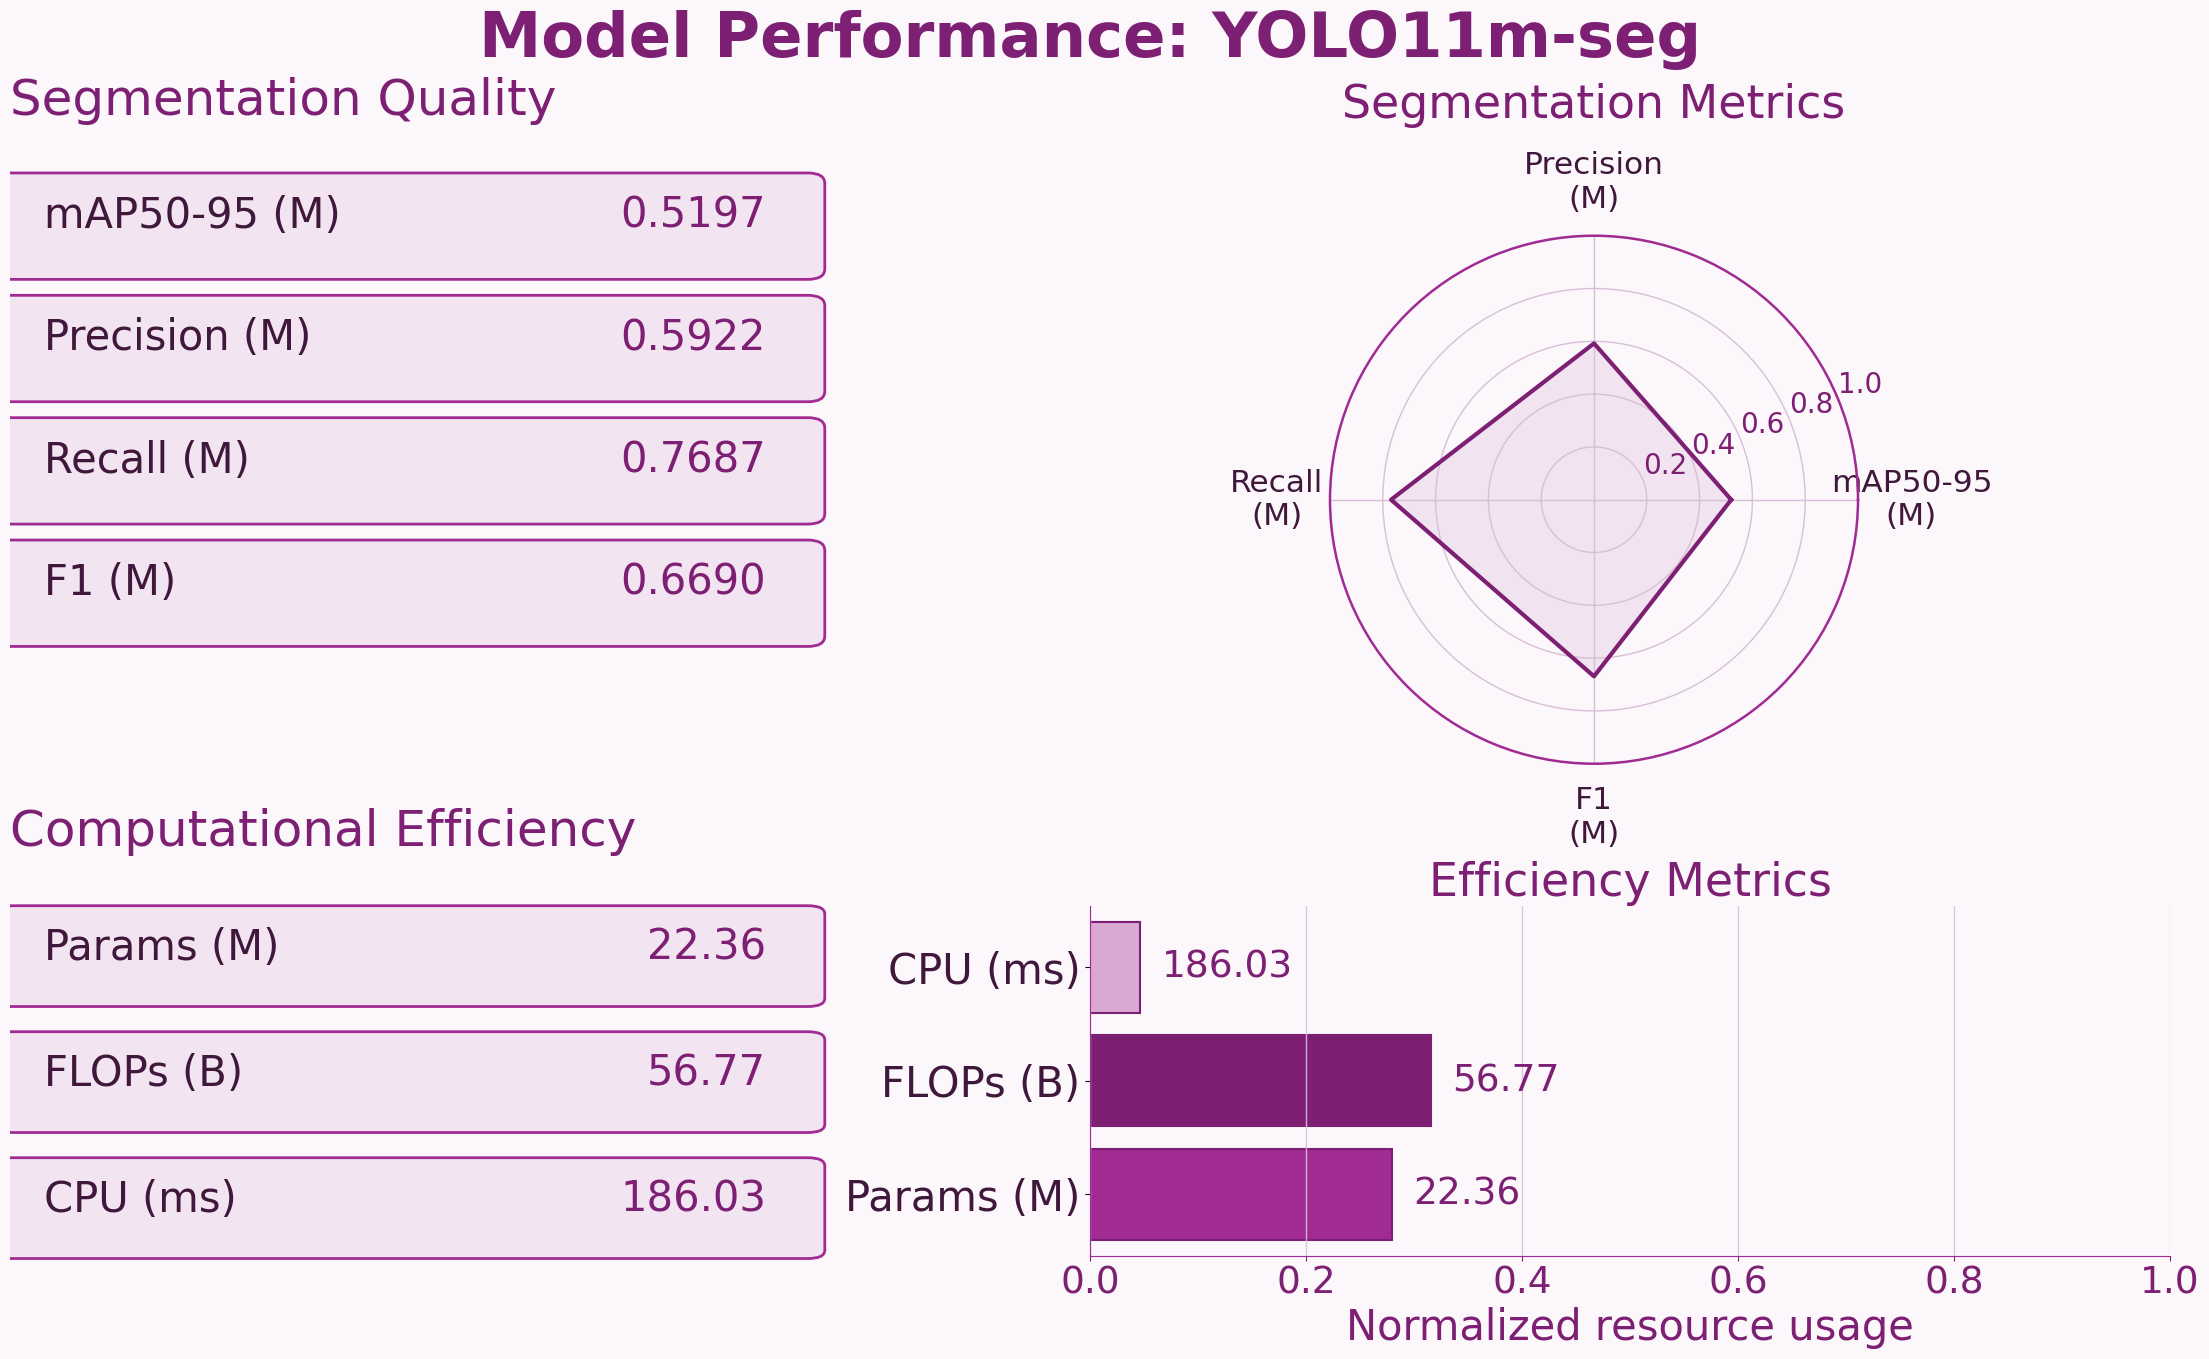

In [29]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyBboxPatch

# =========================
# Datos del modelo seleccionado
# =========================
seg_metrics = {
    "mAP50-95 (M)": 0.5197,
    "Precision (M)": 0.5922,
    "Recall (M)": 0.7687,
    "F1 (M)": 0.6690,
}

eff_metrics = {
    "Params (M)": 22.36,
    "FLOPs (B)": 56.77,
    "CPU (ms)": 186.03,
}

# Paleta en torno al magenta
BG = "#fbf7fb"
PANEL = "#f3e4f2"
ACCENT = "#A02B93"
ACCENT_DARK = "#7d1f73"
ACCENT_LIGHT = "#d9a8d3"
GRID = "#d8bfd8"
TEXT = "#3f183b"

# =========================
# Figura general
# =========================
fig = plt.figure(figsize=(24, 14))
fig.patch.set_facecolor(BG)
fig.suptitle("Model Performance: YOLO11m-seg", fontsize=45, 
             color=ACCENT_DARK,
             fontweight="bold", 
             y=0.99)

# -------------------------
# Panel izquierdo superior: tarjetas segmentación
# -------------------------
ax_cards1 = fig.add_axes([0.05, 0.52, 0.35, 0.38])
ax_cards1.set_facecolor(PANEL)
ax_cards1.axis("off")
ax_cards1.text(0.0, 1.02, "Segmentation Quality", fontsize=36, 
            color=ACCENT_DARK,
            #    fontweight="bold", 
               va="bottom")

y_positions = [0.75, 0.52, 0.29, 0.06]
for (label, value), y in zip(seg_metrics.items(), y_positions):
    box = FancyBboxPatch((0.0, y), 0.95, 0.16,
                         boxstyle="round,pad=0.02",
                         facecolor=PANEL, edgecolor=ACCENT,
                         linewidth=2.0)
    ax_cards1.add_patch(box)
    ax_cards1.text(0.04, y + 0.10, label, fontsize=30, color=TEXT, va="center")
    ax_cards1.text(0.90, y + 0.10, f"{value:.4f}", fontsize=30, color=ACCENT_DARK, va="center", ha="right")

# -------------------------
# Panel derecho superior: radar chart
# -------------------------
labels = list(seg_metrics.keys())
radar_labels = [label.replace(" (", "\n(") for label in labels]
values = list(seg_metrics.values())

angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
values_cycle = values + values[:1]
angles_cycle = angles + angles[:1]

ax_radar = fig.add_axes([0.60, 0.45, 0.22, 0.38], polar=True)
ax_radar.set_facecolor(BG)
ax_radar.plot(angles_cycle, values_cycle, linewidth=3, color=ACCENT_DARK)
ax_radar.fill(angles_cycle, values_cycle, alpha=0.25, color=ACCENT_LIGHT)
ax_radar.set_xticks(angles)
ax_radar.set_xticklabels(radar_labels, fontsize=22.5, color=TEXT)
ax_radar.tick_params(axis="x", pad=28)
ax_radar.set_ylim(0, 1.0)
ax_radar.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax_radar.tick_params(axis="y", labelsize=20, colors=ACCENT_DARK)
ax_radar.grid(color=GRID, linewidth=1.0)
ax_radar.spines["polar"].set_color(ACCENT)
ax_radar.spines["polar"].set_linewidth(1.8)
ax_radar.set_title("Segmentation Metrics", fontsize=33, color=ACCENT_DARK, pad=24)

# -------------------------
# Panel izquierdo inferior: tarjetas eficiencia
# -------------------------
ax_cards2 = fig.add_axes([0.05, 0.08, 0.35, 0.30])
ax_cards2.set_facecolor(PANEL)
ax_cards2.axis("off")
ax_cards2.text(0.0, 1.02, "Computational Efficiency", 
               fontsize=36, 
               color=ACCENT_DARK,
            #    fontweight="bold", 
               va="bottom")

y_positions2 = [0.68, 0.38, 0.08]
for (label, value), y in zip(eff_metrics.items(), y_positions2):
    box = FancyBboxPatch((0.0, y), 0.95, 0.20,
                         boxstyle="round,pad=0.02",
                         facecolor=PANEL, edgecolor=ACCENT,
                         linewidth=2.0)
    ax_cards2.add_patch(box)
    ax_cards2.text(0.04, y + 0.12, label, fontsize=30, color=TEXT, va="center")
    ax_cards2.text(0.90, y + 0.12, f"{value:.2f}", fontsize=30, color=ACCENT_DARK, va="center", ha="right")

# -------------------------
# Panel derecho inferior: barras horizontales
# -------------------------
ax_bar = fig.add_axes([0.50, 0.10, 0.45, 0.25])
ax_bar.set_facecolor(BG)
bar_labels = list(eff_metrics.keys())
bar_vals = list(eff_metrics.values())

# Normalización visual para que compartan escala
norm_vals = [
    eff_metrics["Params (M)"] / 80.0,
    eff_metrics["FLOPs (B)"] / 180.0,
    eff_metrics["CPU (ms)"] / 4000.0,
]

y = np.arange(len(bar_labels))
ax_bar.barh(y, norm_vals, color=[ACCENT, ACCENT_DARK, ACCENT_LIGHT], edgecolor=ACCENT_DARK, linewidth=1.5)
ax_bar.set_yticks(y)
ax_bar.set_yticklabels(bar_labels, fontsize=30, color=TEXT)
ax_bar.set_xlim(0, 1.0)
ax_bar.tick_params(axis="x", labelsize=27, colors=ACCENT_DARK)
ax_bar.set_xlabel("Normalized resource usage", fontsize=30, color=ACCENT_DARK)
ax_bar.set_title("Efficiency Metrics", fontsize=33, color=ACCENT_DARK)
ax_bar.grid(axis="x", color=GRID, linewidth=1.0, alpha=0.9)
ax_bar.spines["top"].set_visible(False)
ax_bar.spines["right"].set_visible(False)
ax_bar.spines["left"].set_color(ACCENT)
ax_bar.spines["bottom"].set_color(ACCENT)
for i, v in enumerate(bar_vals):
    ax_bar.text(norm_vals[i] + 0.02, i, f"{v:.2f}", va="center", fontsize=27, color=ACCENT_DARK)

plt.savefig("metrics_mosaic_yolo11m.png", dpi=300, bbox_inches="tight")
plt.savefig("metrics_mosaic_yolo11m.pdf", bbox_inches="tight")
plt.show()